In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [3]:
df = pd.read_csv('/content/Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [4]:
df.shape
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [5]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [6]:
df.dtypes

,0
YearsExperience,float64
Salary,int64


In [7]:
X = df[['YearsExperience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(24, 1) (6, 1)


In [8]:
X_train.describe()
y_train.describe()

,Salary
count,24.000000
mean,74207.625000
std,28240.733473
min,37731.000000
25%,55456.750000
50%,62164.500000
75%,99030.250000
max,122391.000000


In [9]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


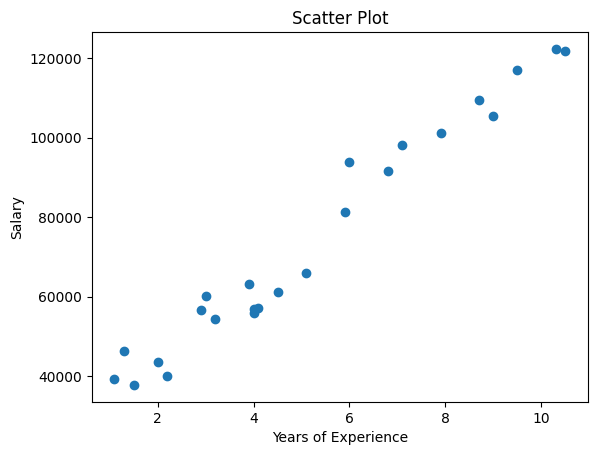

In [10]:
plt.scatter(X_train, y_train)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Scatter Plot")
plt.show()

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

Intercept: 25321.583011776813
Slope: [9423.81532303]


In [12]:
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     598.4
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           1.91e-17
Time:                        11:24:15   Log-Likelihood:                -239.44
No. Observations:                  24   AIC:                             482.9
Df Residuals:                      22   BIC:                             485.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.532e+04   2285.938     

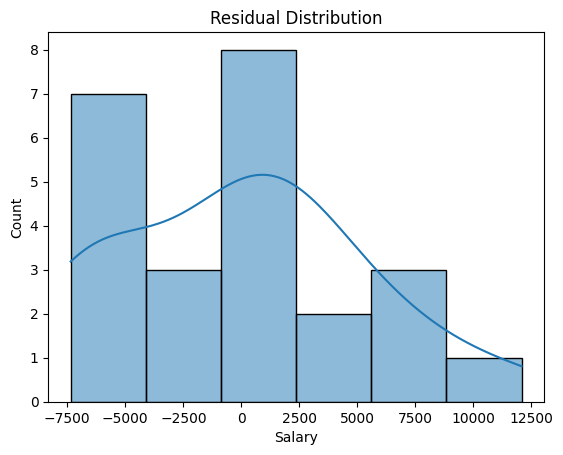

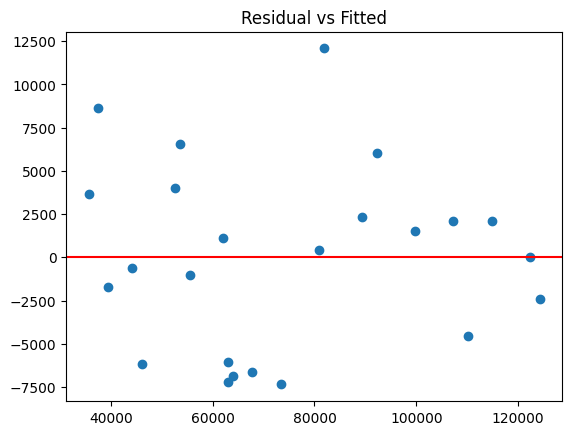

In [13]:
residuals = y_train - model.predict(X_train)

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

plt.scatter(model.predict(X_train), residuals)
plt.axhline(0, color='red')
plt.title("Residual vs Fitted")
plt.show()

In [14]:
y_train_pred = model.predict(X_train)

mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(mse_train, r2_train)

27102249.73126139 0.9645401573418146


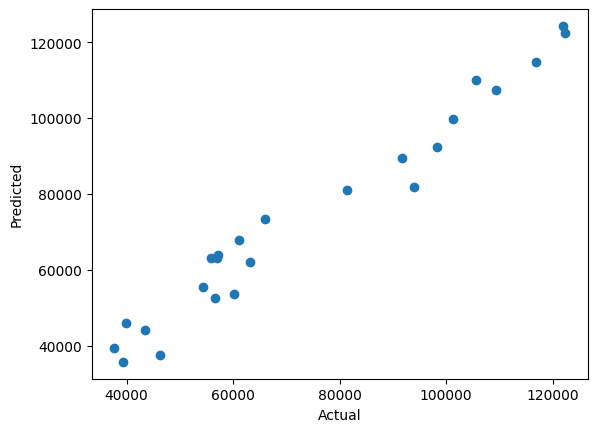

In [15]:
plt.scatter(y_train, y_train_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

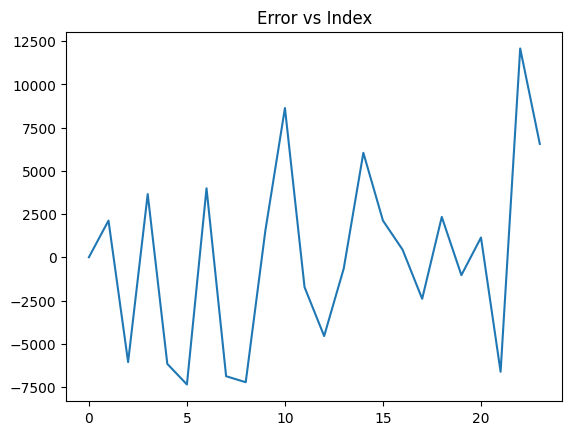

In [16]:
plt.plot(residuals.values)
plt.title("Error vs Index")
plt.show()

In [17]:
y_test_pred = model.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(mse_test, r2_test)

49830096.85590839 0.9024461774180497


In [18]:
data = {
    'Height': [150, 155, 160, 165, 170, 175, 180],
    'Marks': [60, 62, 65, 68, 70, 72, 75]
}

df2 = pd.DataFrame(data)